# Python Course: Final Assignment
# Part 2: Classification Analysis
# Data Subject : Predicting House Price Category (Affordable vs. Expensive)
# Author Stavros Stavropoulos

Step 1

In [1]:
# Let's start with step 1, which is about setting up the environment for our classification task.
# Don't forget to select the appropriate Kernel at the top right
# We import the necessary libraries for the data setup for classification. 
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression # In classification we use logistic regression instead of linear regression.
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score # These are the metrics we will use to evaluate our classification model.

base_path = Path('.').resolve()
train_path = base_path / 'data' / 'train_sample.csv'


df = pd.read_csv(train_path, sep=';') # This line loads the dataset.
# Now lets automatically find all the numeric columns in the dataset, because correlation analysis only works with numeric data.
numeric_df = df.select_dtypes(include=[np.number]) # This line creates a new DataFrame that includes only the numeric columns from the original dataset.

# We calculate the correlations and take the 6 most important ones (excluding SalePrice).
correlations = numeric_df.corr()['SalePrice'].sort_values(ascending=False) # This line calculates the correlation of all the numeric features with the target variable SalePrice and sorts them in descending order.
auto_features = correlations.index[1:7].tolist() # We take the top 6 features that are the most positively correlated with our variable SalePrice, excluding the first one which is SalePrice itself.

df_cleaned = df[auto_features + ['SalePrice']].dropna() # This line filters the DataFrame and cleans the blanks.

print(f" Automated Selection: The model will use the top {len(auto_features)} correlated features.")
print(f"Features selected: {auto_features}")
print(f"✅ Cleaned Dataset Shape: {df_cleaned.shape}") 
# Those lines just print out the results of the automated featured selection process and the shape of the cleaned dataset.

 Automated Selection: The model will use the top 6 correlated features.
Features selected: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF']
✅ Cleaned Dataset Shape: (1460, 7)


Step 2

📊 Classification Target Created.
Median Price Threshold: $163,000.00
Class Distribution:
IsExpensive
0    732
1    728
Name: count, dtype: int64


C:\Users\Σταυρος\AppData\Local\Temp\ipykernel_9492\4076977294.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IsExpensive', data=df_cleaned, palette='coolwarm') # This line creates a count plot using seaborn to show the distribution of the IsExpensive classes in our dataset.


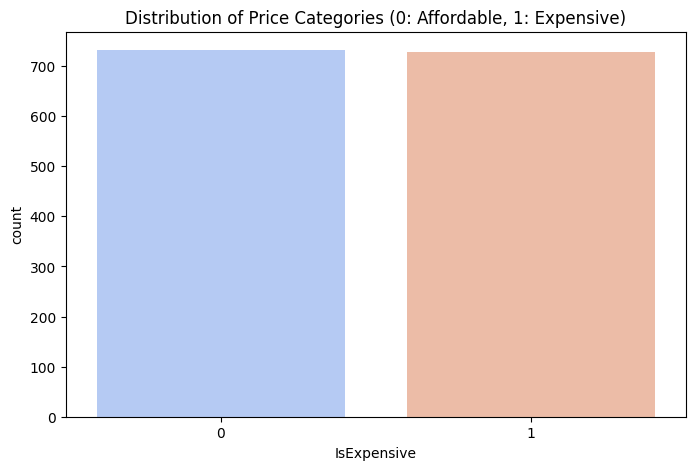

In [2]:
# Now for step 2, we will calculate our median price and split the dataset into Affordable and Expensive categories.
median_val = df_cleaned['SalePrice'].median() # This line calculates the median value of SalePrice and stores it into median_val.
df_cleaned['IsExpensive'] = (df_cleaned['SalePrice'] > median_val).astype(int) # This now creates a binary target 1 if Price > than Median and 0 otherwise.
print(f"📊 Classification Target Created.")
print(f"Median Price Threshold: ${median_val:,.2f}")
print(f"Class Distribution:\n{df_cleaned['IsExpensive'].value_counts()}") # Those lines print out the results of the classification target creation.

plt.figure(figsize=(8, 5)) # This line sets the size of the plot.
sns.countplot(x='IsExpensive', data=df_cleaned, palette='coolwarm') # This line creates a count plot using seaborn to show the distribution of the IsExpensive classes in our dataset.
plt.title('Distribution of Price Categories (0: Affordable, 1: Expensive)') 
plt.show() # Those lines create a count plot so that we can visually see the split between the two classes in our target variable.



Step 3

In [3]:
# Now we will split the data into training and testing sets. We will use 80% of the data for training and 20% for testing.
X = df_cleaned[auto_features] # X will contain the features that we selected earlier.
y = df_cleaned['IsExpensive'] # Y will contain the target variable that we just created.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # This line splits the data into training and testing sets.
print(f"✅ Data split complete!")
print(f"Training on {X_train.shape[0]} samples, Testing on {X_test.shape[0]} samples.") 
# Those lines print out the results of the data splitting process, so that we can see how many samples are in the training and testing sets.

✅ Data split complete!
Training on 1168 samples, Testing on 292 samples.


Step 4

In [4]:
# Now for step 4 we will train a logistic regression model on the training data and we will evaluate it on the testing data.
clf = LogisticRegression(max_iter=1000) # This line initializes a logistic regression classifier. We set max_iter to 1000 to make sure it converges.
clf.fit(X_train, y_train) # This line fits the logistic regression model to the training data.
y_pred = clf.predict(X_test) # This line makes predictions on the testing data using the trained model.
print("✅ Classification model trained and predictions generated.Yeejj!")

✅ Classification model trained and predictions generated.Yeejj!


Step 5

 Accuracy Score: 0.9007


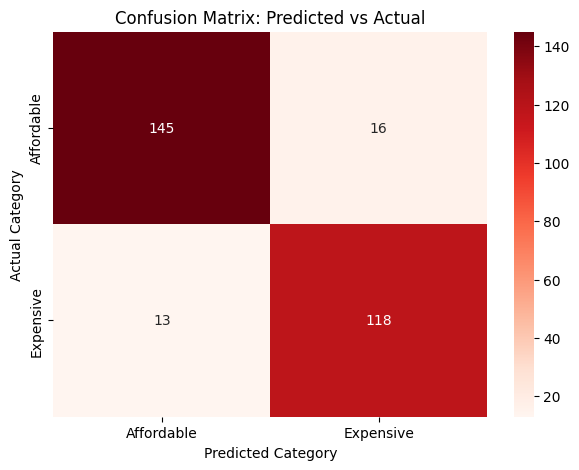


Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       161
           1       0.88      0.90      0.89       131

    accuracy                           0.90       292
   macro avg       0.90      0.90      0.90       292
weighted avg       0.90      0.90      0.90       292



In [5]:
# Now for step 5 we will try and see how well our model performed using the confusion matrix and classification report.
# This shows us where the model got confused.
accuracy = accuracy_score(y_test, y_pred) # This line calculates the accuracy score of our model by comparing the true labels (y_test) with the predicted labels (y_pred).
print(f" Accuracy Score: {accuracy:.4f}") # This line prints out the results of the accuracy score.

# And now we try to visualize the confusion matrix.
cm = confusion_matrix(y_test, y_pred) 
plt.figure(figsize=(7, 5)) # This line sets the size of the plot for the confusion matrix.
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',   # This line creates a heatmap to visualize the confusion matrix using seaborn. The annot=True argument adds the numbers to the cells, fmt='d' formats them as integers, and cmap='Red' sets the color scheme.
            xticklabels=['Affordable', 'Expensive'], 
            yticklabels=['Affordable', 'Expensive']) 
plt.title('Confusion Matrix: Predicted vs Actual')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show() # Those lines create a heatmap to visualize the confusion matrix, which shows how many samples were correctly and incorrectly classified by our model.

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))
# Those 2 lines above print out the classification report.

As we can see our model achieved an impressive 90% accuracy, demonstrating that it can reliably distinguish between affordable and expensive houses. This high performance confirms that the features we selected most notably Overall Quality and Living Area are indeed the primary drivers of a home's market value at the moment. By using both regression and classification we have managed to build a consistent and robust framework as a result we can not only estimate a specific sale price with low error but also accurately categorize a property's market segment. This combination between our two models proves that our data cleaning and feature selection were highly effective, leading to dependable results that reflect real-world housing trends.